In [1]:
import numpy as np
import matplotlib.pyplot as plt

We will solve Hooke's law for a linear mass-spring system. Hooke's Law can be written as follows.

$$  F_{Total} = \sum_i F_i = \sum_i m_ia_i = \sum_i\bigg[ -k_{i-1,i}(x_i-x_{i-1}) + k_{i,i+1}(x_{i+1} - x_{i})\bigg] = \sum_i \bigg[k_{i-1,i}x_{i-1} - (k_{i,i+1}+k_{i-1,i})x_i + k_{i,i+1}x_{i+1}\bigg]$$

We can generalize this into the matrix equation 

$$M\vec a = K\vec x $$

where 

$$M = \begin{bmatrix} m_1 & 0 & 0 &  & 0 \\ 0 & m_2 & 0 & \cdots & 0 \\ 0 & 0 & m_3 & & 0 \\ & \vdots & & \ddots & \vdots\\ 0 & 0 & 0 & \cdots & m_N \end{bmatrix},$$

$$K = \begin{bmatrix} -k_{1,2} & k_{1,2}  & 0 &  &0 & 0 \\ k_{1,2} & -(k_{1,2} + k_{2,3}) & k_{2,3} & \cdots &0 & 0 \\ 0 & k_{2,3} & -(k_{2,3} + k_{3,4}) & & 0 & 0 \\ & \vdots & & \ddots & \vdots & \vdots\\ 0 & 0 & 0 & \cdots & -(k_{N-2, N-1} + k_{N-1, N}) & k_{N-1, N} \\0 & 0 & 0 & \cdots & k_{N-1, N} & -k_{N-1, N} \end{bmatrix}, \text{ and}$$

$$ \vec x = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_N \end{bmatrix} $$

In [2]:
M_C = 12  #Mass of Carbon (amu)
M_O = 16  #Mass of Oxygen (amu)

K_CO = 11.03  #Force constant between Carbon and Oxygen (N/cm) from https://www.researchgate.net/figure/Wavenumber-and-bond-force-constant-that-assume-the-form-of-symmetrical-stretching-of-the_tbl2_340900697
K_CC = 8.395  #Force constant between Carbons (N/cm) from https://www.researchgate.net/figure/Wavenumber-and-bond-force-constant-that-assume-the-form-of-symmetrical-stretching-of-the_tbl2_340900697

N_C = 3   #Number of Carbon atoms
N_O = 2   #Number of Oxygen atoms

klist = [K_CO] + N_C*[K_CC] + [K_CO] #List of force constants in order for making the K matrix later
mlist = [M_O] + N_C*[M_C] + [M_O] #List of masses in order

In [3]:
kmatrix = []
mmatrix = []

#K Matrix
for i, k in enumerate(klist):
    krow = np.zeros(len(klist)) #Add one so that it has the same dimensions as M
    if i == 0:
        krow[i] = -k
        krow[i+1] = k
        kmatrix.append(krow)
    elif i == len(klist)-1:
        krow[i] = -k
        krow[i-1] = k
        kmatrix.append(krow)
    else:
        krow[i-1] = klist[i-1]
        krow[i] = -(klist[i-1] + k)
        krow[i+1] = k
        kmatrix.append(krow)

#M Matrix
for i, m in enumerate(mlist):
    mrow = np.zeros(len(mlist))
    mrow[i] = m
    mmatrix.append(mrow)

In [4]:
#Produce matrix for which we'll find the eigenvalues
MinvK = np.linalg.inv(mmatrix)@kmatrix

#Find the eigenvalues and eigenvectors

evals, evecs = np.linalg.eig(MinvK)

print(evals, evecs)

[-2.62364797e+00 -1.93943231e+00 -9.84421751e-01 -4.16535328e-17
 -2.48331300e-01] [[ 0.22068849  0.30494925  0.39967468 -0.4472136  -0.55082568]
 [-0.61921565 -0.5529705  -0.17105743 -0.4472136  -0.35240355]
 [ 0.59949833 -0.14718951 -0.68022519 -0.4472136   0.03339158]
 [-0.4300868   0.66664021 -0.23221109 -0.4472136   0.40733369]
 [ 0.15328296 -0.36763522  0.54255986 -0.4472136   0.63668444]]


What we have produced are the eiganvalues and eigenvectors coresponding to the eigenvalue equation:

$$ M^{-1}K \ddot{\vec x} = \lambda \vec x$$

We can assume harmonic solutions, $\vec x = \vec A  e^{i\omega t} \longrightarrow \ddot{\vec x} = -\omega^2\vec x$. Placing this into the eigenvalue equation, we clearly see that 

$$\omega = \sqrt{|\lambda|}$$

So if we take the square root of the eigenvalues we found, we'll have the frequencies in $rad/s$.

We can also plot the displacements fto display the normal modes.

\nEigenfrequencies $(cm^{-1})$:
Mode 1: 1.62 rad/s
Mode 2: 1.39 rad/s
Mode 3: 0.99 rad/s
Mode 4: 0.00 rad/s
Mode 5: 0.50 rad/s


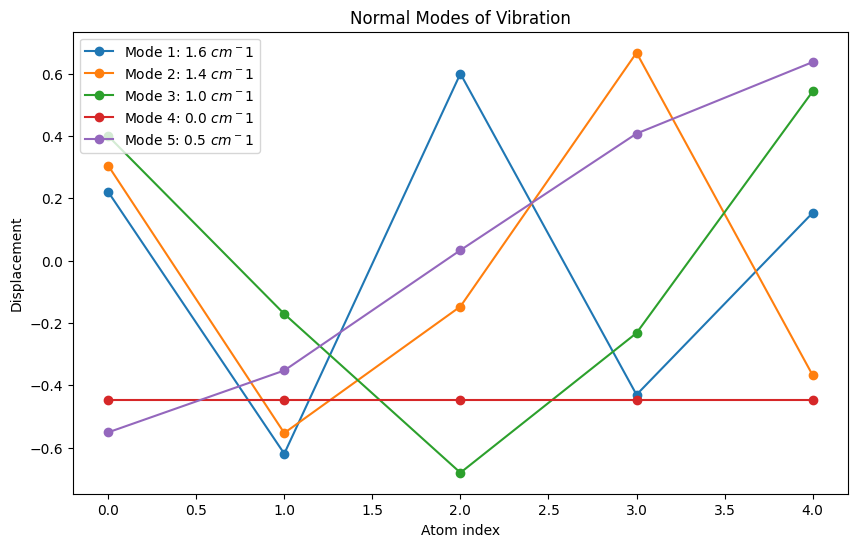

In [8]:
frequencies = np.sqrt(np.abs(evals))

print(r"\nEigenfrequencies $(cm^{-1})$:")
for i, freq in enumerate(frequencies):
    print(f"Mode {i+1}: {freq:.2f} rad/s")

# Plot the normal modes
plt.figure(figsize=(10, 6))
for i in range(len(frequencies)):
    plt.plot(evecs[:, i], 'o-', label=f'Mode {i+1}: {frequencies[i]:.1f} $rad/s$')
plt.title('Normal Modes of Vibration')
plt.xlabel('Atom index')
plt.ylabel('Displacement')
plt.legend()
plt.show()

# Part b)

I'm literally just going to copy and paste everything from part a) but replace N_C with 9. 

I could put everything in a function and make it easy to just produce all of this in one line but I'm dead too lazy to do that. 

In [9]:
M_C = 12  #Mass of Carbon (amu)
M_O = 16  #Mass of Oxygen (amu)

K_CO = 11.03  #Force constant between Carbon and Oxygen (N/cm) from https://www.researchgate.net/figure/Wavenumber-and-bond-force-constant-that-assume-the-form-of-symmetrical-stretching-of-the_tbl2_340900697
K_CC = 8.395  #Force constant between Carbons (N/cm) from https://www.researchgate.net/figure/Wavenumber-and-bond-force-constant-that-assume-the-form-of-symmetrical-stretching-of-the_tbl2_340900697

N_C = 9   #Number of Carbon atoms
N_O = 2   #Number of Oxygen atoms

klist = [K_CO] + N_C*[K_CC] + [K_CO] #List of force constants in order for making the K matrix later
mlist = [M_O] + N_C*[M_C] + [M_O] #List of masses in order

In [10]:
kmatrix = []
mmatrix = []

#K Matrix
for i, k in enumerate(klist):
    krow = np.zeros(len(klist)) #Add one so that it has the same dimensions as M
    if i == 0:
        krow[i] = -k
        krow[i+1] = k
        kmatrix.append(krow)
    elif i == len(klist)-1:
        krow[i] = -k
        krow[i-1] = k
        kmatrix.append(krow)
    else:
        krow[i-1] = klist[i-1]
        krow[i] = -(klist[i-1] + k)
        krow[i+1] = k
        kmatrix.append(krow)

#M Matrix
for i, m in enumerate(mlist):
    mrow = np.zeros(len(mlist))
    mrow[i] = m
    mmatrix.append(mrow)

In [11]:
#Produce matrix for which we'll find the eigenvalues
MinvK = np.linalg.inv(mmatrix)@kmatrix

#Find the eigenvalues and eigenvectors

evals, evecs = np.linalg.eig(MinvK)

\nEigenfrequencies $(cm^{-1})$:
Mode 1: 1.66 rad/s
Mode 2: 1.62 rad/s
Mode 3: 1.54 rad/s
Mode 4: 1.43 rad/s
Mode 5: 1.28 rad/s
Mode 6: 1.10 rad/s
Mode 7: 0.91 rad/s
Mode 8: 0.69 rad/s
Mode 9: 0.00 rad/s
Mode 10: 0.23 rad/s
Mode 11: 0.46 rad/s


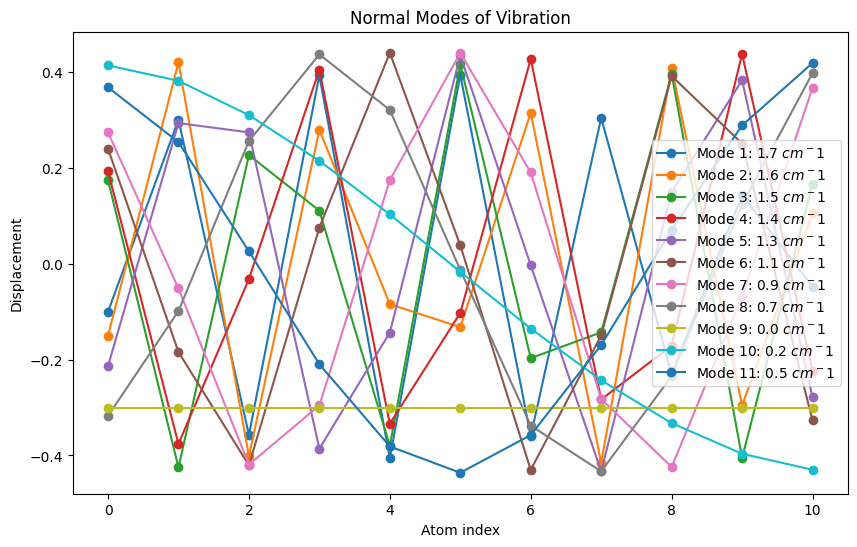

In [12]:
frequencies = np.sqrt(np.abs(evals))

print(r"\nEigenfrequencies $(cm^{-1})$:")
for i, freq in enumerate(frequencies):
    print(f"Mode {i+1}: {freq:.2f} rad/s")

# Plot the normal modes
plt.figure(figsize=(10, 6))
for i in range(len(frequencies)):
    plt.plot(evecs[:, i], 'o-', label=f'Mode {i+1}: {frequencies[i]:.1f} $rad/s$')
plt.title('Normal Modes of Vibration')
plt.xlabel('Atom index')
plt.ylabel('Displacement')
plt.legend()
plt.show()

Some of those modes are weird looking. I'm not sure if this is correct.

What if I do like 1000

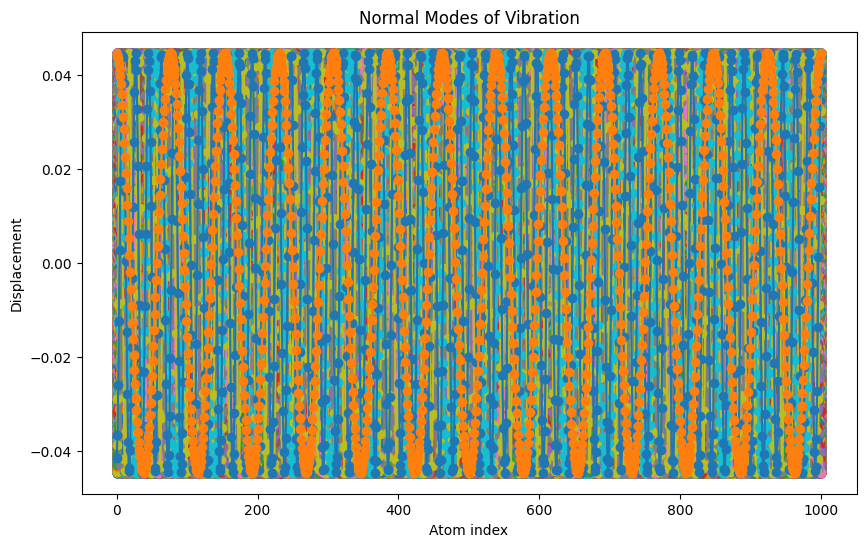

In [15]:
M_C = 12  #Mass of Carbon (amu)
M_O = 16  #Mass of Oxygen (amu)

K_CO = 11.03  #Force constant between Carbon and Oxygen (N/cm) from https://www.researchgate.net/figure/Wavenumber-and-bond-force-constant-that-assume-the-form-of-symmetrical-stretching-of-the_tbl2_340900697
K_CC = 8.395  #Force constant between Carbons (N/cm) from https://www.researchgate.net/figure/Wavenumber-and-bond-force-constant-that-assume-the-form-of-symmetrical-stretching-of-the_tbl2_340900697

N_C = 1000   #Number of Carbon atoms
N_O = 2   #Number of Oxygen atoms

klist = [K_CO] + N_C*[K_CC] + [K_CO] #List of force constants in order for making the K matrix later
mlist = [M_O] + N_C*[M_C] + [M_O] #List of masses in order
kmatrix = []
mmatrix = []

#K Matrix
for i, k in enumerate(klist):
    krow = np.zeros(len(klist)) #Add one so that it has the same dimensions as M
    if i == 0:
        krow[i] = -k
        krow[i+1] = k
        kmatrix.append(krow)
    elif i == len(klist)-1:
        krow[i] = -k
        krow[i-1] = k
        kmatrix.append(krow)
    else:
        krow[i-1] = klist[i-1]
        krow[i] = -(klist[i-1] + k)
        krow[i+1] = k
        kmatrix.append(krow)

#M Matrix
for i, m in enumerate(mlist):
    mrow = np.zeros(len(mlist))
    mrow[i] = m
    mmatrix.append(mrow)

#Produce matrix for which we'll find the eigenvalues
MinvK = np.linalg.inv(mmatrix)@kmatrix

#Find the eigenvalues and eigenvectors

evals, evecs = np.linalg.eig(MinvK)

frequencies = np.sqrt(np.abs(evals))

'''
print(r"\nEigenfrequencies $(cm^{-1})$:")
for i, freq in enumerate(frequencies):
    print(f"Mode {i+1}: {freq:.2f} rad/s")
'''

# Plot the normal modes
plt.figure(figsize=(10, 6))
for i in range(len(frequencies)):
    plt.plot(evecs[:, i], 'o-', label=f'Mode {i+1}: {frequencies[i]:.1f} $cm^{-1}$')
plt.title('Normal Modes of Vibration')
plt.xlabel('Atom index')
plt.ylabel('Displacement')
#plt.legend()
plt.show()

whoa